<a href="https://colab.research.google.com/github/trin08/rchoc-inq10-study/blob/main/generate_workflow_diagram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

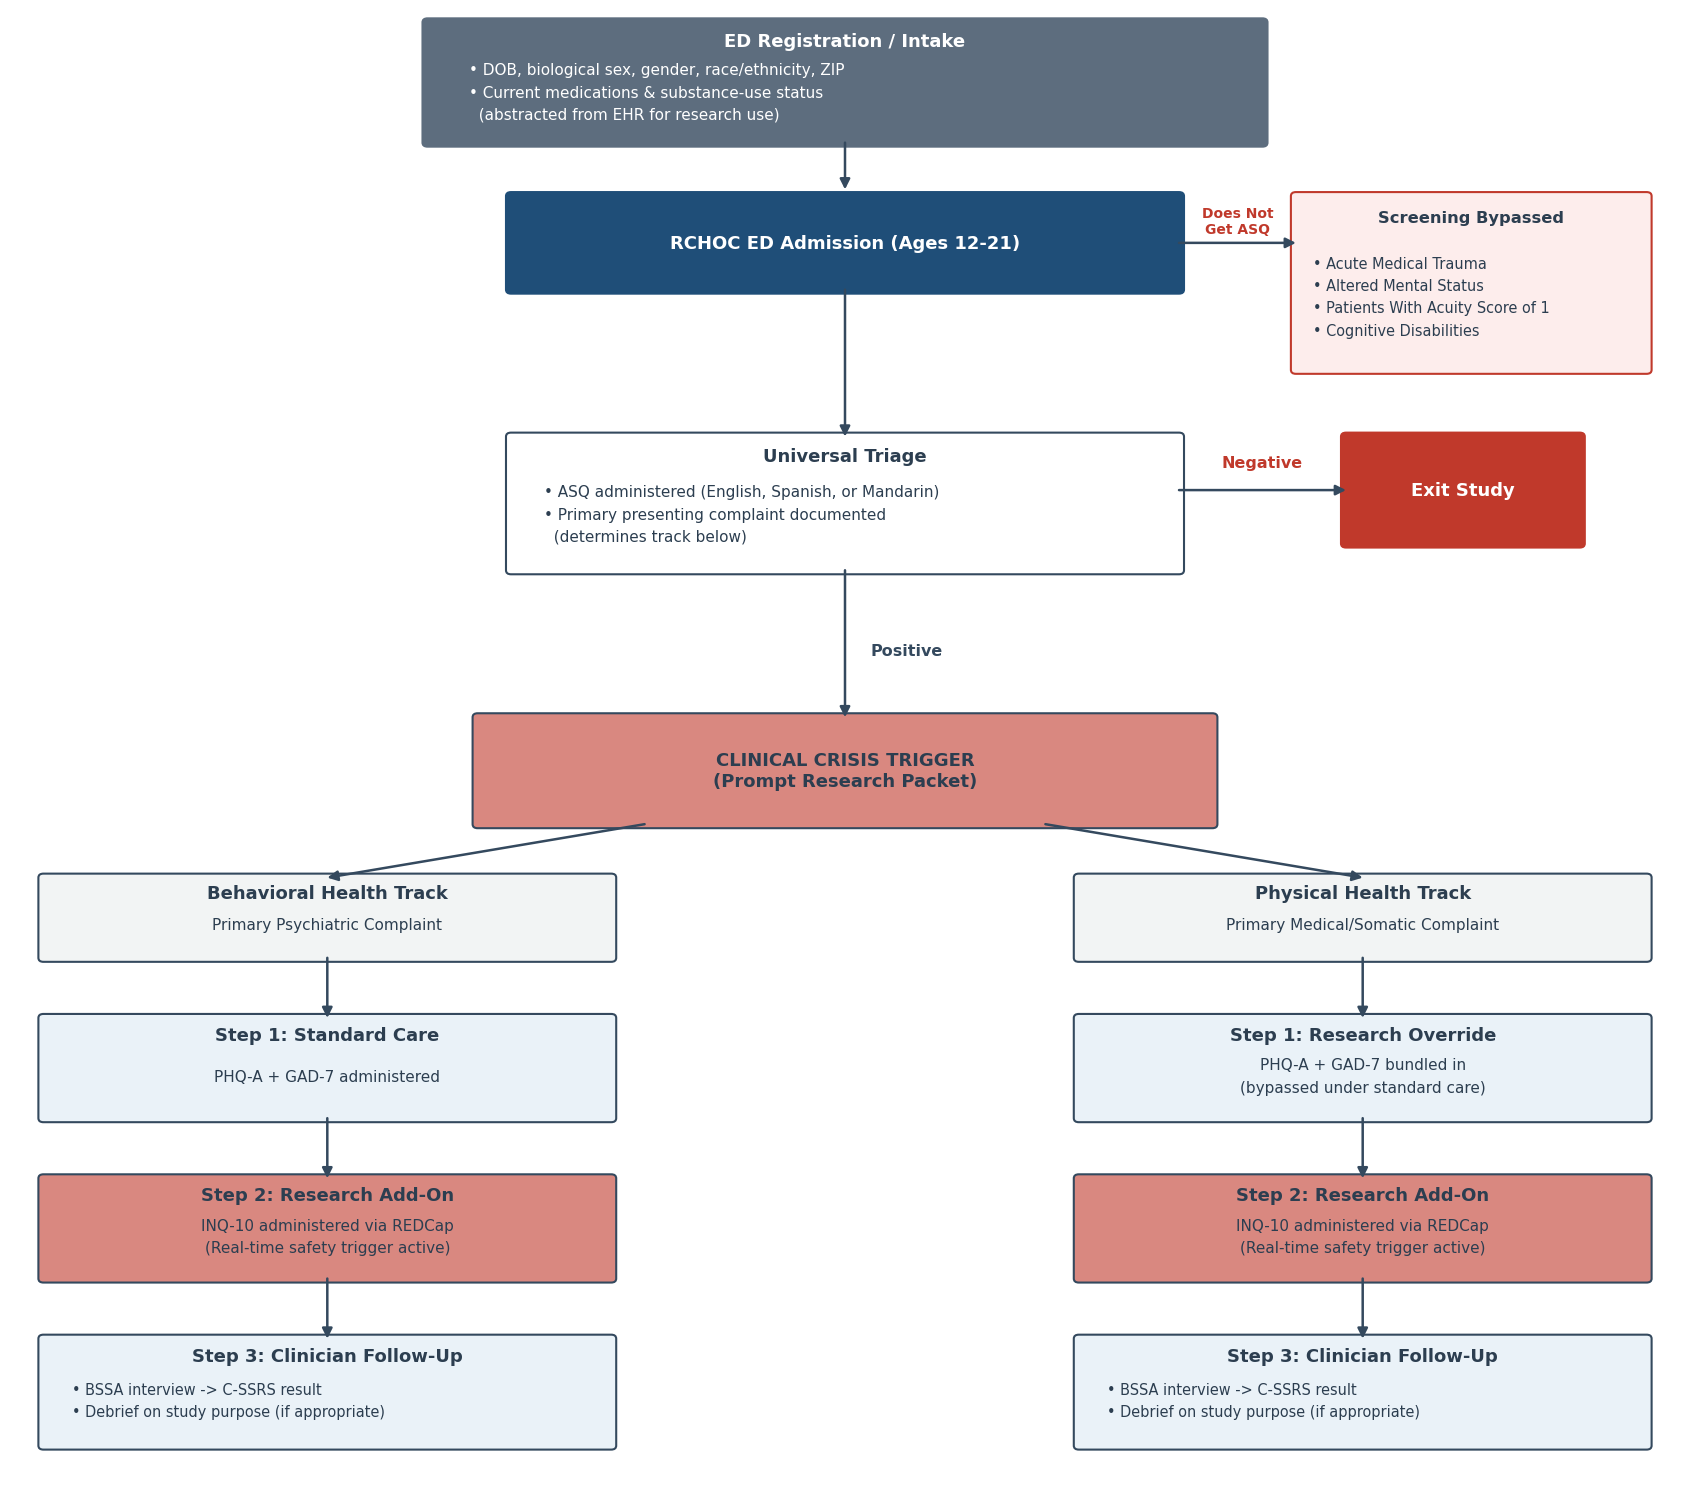

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(17, 15), facecolor='#FFFFFF')
ax.set_xlim(0, 100)
ax.set_ylim(0, 110)
ax.axis('off')

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']

COLOR_PRIMARY = '#1F4E78'
COLOR_ALERT = '#C0392B'
COLOR_TRIGGER = '#D98880'
COLOR_TRACK = '#F2F4F4'
COLOR_STEP = '#EAF2F8'
COLOR_TEXT_DARK = '#2C3E50'
COLOR_BORDER = '#34495E'
COLOR_REGISTRATION = '#5D6D7E'

def draw_custom_box(title, body_lines, x, y, w, h, bg_color, border_color=COLOR_BORDER,
                    text_color=COLOR_TEXT_DARK, title_scale=1.0, body_scale=1.0):

    # 1. Draw the Bounding Box
    rect = patches.FancyBboxPatch(
        (x, y), w, h, boxstyle="round,pad=0.3",
        facecolor=bg_color, edgecolor=border_color, linewidth=1.5, zorder=1
    )
    ax.add_patch(rect)

    # 2. Set Stable Font Sizes
    title_size = 13 * title_scale
    body_size = 11 * body_scale

    # 3. Draw Title (Anchored to the top with safe padding)
    if title:
        title_y = y + h - (h * 0.08) if body_lines else y + h / 2
        ax.text(x + w / 2, title_y, title, ha='center', va='top' if body_lines else 'center',
                color=text_color, fontsize=title_size, weight='bold', zorder=2)

    # 4. Draw Body Lines (Leveraging native multiline alignment)
    if body_lines:
        body_text = "\n".join(body_lines)
        alignment = 'left' if body_text.strip().startswith('•') else 'center'
        text_x = x + w * 0.05 if alignment == 'left' else x + w / 2

        # Center the body text block in the remaining vertical space
        body_y = y + h * 0.42 if title else y + h / 2

        ax.text(text_x, body_y, body_text, ha=alignment, va='center', color=text_color,
                fontsize=body_size, linespacing=1.6, zorder=2)

def draw_clean_arrow(x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", facecolor=COLOR_BORDER, edgecolor=COLOR_BORDER,
                                linewidth=1.8, mutation_scale=15, shrinkA=0, shrinkB=0))

# ----------------- 0. Registration / Intake -----------------
reg_body = [
    "• DOB, biological sex, gender, race/ethnicity, ZIP",
    "• Current medications & substance-use status",
    "  (abstracted from EHR for research use)"
]
draw_custom_box("ED Registration / Intake", reg_body, 25, 100, 50, 9,
                bg_color=COLOR_REGISTRATION, border_color=COLOR_REGISTRATION, text_color='white')

draw_clean_arrow(50, 100, 50, 96.5)

# ----------------- 1. RCHOC ED Admission -----------------
draw_custom_box("RCHOC ED Admission (Ages 12-21)", None, 30, 89, 40, 7,
                bg_color=COLOR_PRIMARY, border_color=COLOR_PRIMARY, text_color='white')

draw_clean_arrow(50, 89, 50, 78)
draw_clean_arrow(70, 92.5, 77, 92.5)

# FIXED: Stacked the text so it perfectly fits the 7-unit wide gap
ax.text(73.5, 93, "Does Not\nGet ASQ", ha='center', va='bottom', color=COLOR_ALERT, fontsize=10, weight='bold')

why_text = [
    "• Acute Medical Trauma",
    "• Altered Mental Status",
    "• Patients With Acuity Score of 1",
    "• Cognitive Disabilities"
]
draw_custom_box("Screening Bypassed", why_text, 77, 83, 21, 13, bg_color='#FDEDEC',
                border_color=COLOR_ALERT, title_scale=0.9, body_scale=0.95)

# ----------------- 2. Triage -----------------
triage_body = [
    "• ASQ administered (English, Spanish, or Mandarin)",
    "• Primary presenting complaint documented",
    "  (determines track below)"
]
draw_custom_box("Universal Triage", triage_body, 30, 68, 40, 10, bg_color='#FFFFFF')

draw_clean_arrow(70, 74, 80, 74)
ax.text(75, 75.5, "Negative", ha='center', va='bottom', color=COLOR_ALERT, fontsize=11.5, weight='bold')

draw_clean_arrow(50, 68, 50, 57)
ax.text(51.5, 62, "Positive", ha='left', va='center', color=COLOR_BORDER, fontsize=11.5, weight='bold')

draw_custom_box("Exit Study", None, 80, 70, 14, 8, bg_color=COLOR_ALERT, border_color=COLOR_ALERT, text_color='white')

# ----------------- 3. Clinical Crisis Trigger -----------------
draw_custom_box("CLINICAL CRISIS TRIGGER\n(Prompt Research Packet)", None, 28, 49, 44, 8,
                bg_color=COLOR_TRIGGER, border_color=COLOR_BORDER, text_color=COLOR_TEXT_DARK)

draw_clean_arrow(38, 49, 19, 45)
draw_clean_arrow(62, 49, 81, 45)

# ----------------- 4. Behavioral Health Track -----------------
LX, LW = 2, 34

draw_custom_box("Behavioral Health Track", ["Primary Psychiatric Complaint"], LX, 39, LW, 6, COLOR_TRACK)

draw_clean_arrow(19, 39, 19, 34.5)
draw_custom_box("Step 1: Standard Care", ["PHQ-A + GAD-7 administered"], LX, 27, LW, 7.5, COLOR_STEP)

draw_clean_arrow(19, 27, 19, 22.5)
draw_custom_box("Step 2: Research Add-On", ["INQ-10 administered via REDCap", "(Real-time safety trigger active)"], LX, 15, LW, 7.5, COLOR_TRIGGER)

draw_clean_arrow(19, 15, 19, 10.5)

# FIXED: Added debriefing note and expanded box height slightly (h=8)
step3_body = [
    "• BSSA interview -> C-SSRS result",
    "• Debrief on study purpose (if appropriate)"
]
draw_custom_box("Step 3: Clinician Follow-Up", step3_body, LX, 2.5, LW, 8, COLOR_STEP, body_scale=0.95)

# ----------------- 5. Physical Health Track -----------------
RX, RW = 64, 34

draw_custom_box("Physical Health Track", ["Primary Medical/Somatic Complaint"], RX, 39, RW, 6, COLOR_TRACK)

draw_clean_arrow(81, 39, 81, 34.5)
draw_custom_box("Step 1: Research Override",
                ["PHQ-A + GAD-7 bundled in", "(bypassed under standard care)"],
                RX, 27, RW, 7.5, COLOR_STEP)

draw_clean_arrow(81, 27, 81, 22.5)
draw_custom_box("Step 2: Research Add-On", ["INQ-10 administered via REDCap", "(Real-time safety trigger active)"], RX, 15, RW, 7.5, COLOR_TRIGGER)

draw_clean_arrow(81, 15, 81, 10.5)

# FIXED: Added debriefing note and expanded box height slightly (h=8)
draw_custom_box("Step 3: Clinician Follow-Up", step3_body, RX, 2.5, RW, 8, COLOR_STEP, body_scale=0.95)

plt.tight_layout()
plt.savefig("RCHOC_ED_Study_Workflow_v7.png", dpi=300, bbox_inches='tight')
plt.show()